# Gated Interpolation Model — Walkthrough

This notebook walks through the model in `src/model.py` piece by piece: the
synthetic data it's trained on, the two pathways, the leak-proofing (with an
empirical check, not just an argument), and one live training run you can
watch converge. It ends by loading the full Experiment 1 grid results.

See `docs/research_spec.md` for the research spec, and
`results/experiment1_findings.md` for the write-up of what this experiment
found (including two real bugs caught and fixed along the way — this
notebook uses the fixed version of everything).


In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import torch
import matplotlib.pyplot as plt

from jump_diffusion_generator import JumpDiffusionGenerator
from src.model import GatedInterpolationModel, TemporalPathway, CrossSectionalPathway
from src.data import make_panel
from src.train import train_one_run

torch.manual_seed(0)
%matplotlib inline


## 1. The synthetic data

`JumpDiffusionGenerator` simulates a multi-asset panel where cross-asset
coupling is a *known, tunable parameter* (`rho`), not something we have to
estimate to check our work against. That's the whole point of using
synthetic data first: we get to grade the model against ground truth before
ever touching real markets (see spec §3, §5).

- `rho=0`: assets diffuse independently.
- `rho=1`: all assets driven by one common Brownian motion (perfect
  correlation).

Sanity check below: does realized correlation actually track `rho` the way
the generator's math says it should? (It should, closely — this is
literally what the generator was designed to produce. If this cell didn't
show a clean upward trend, the generator itself would be broken.)


rho=0.0  ->  mean off-diagonal realized corr = 0.018
rho=0.2  ->  mean off-diagonal realized corr = 0.176
rho=0.4  ->  mean off-diagonal realized corr = 0.331


rho=0.6  ->  mean off-diagonal realized corr = 0.486
rho=0.8  ->  mean off-diagonal realized corr = 0.641


rho=1.0  ->  mean off-diagonal realized corr = 0.795


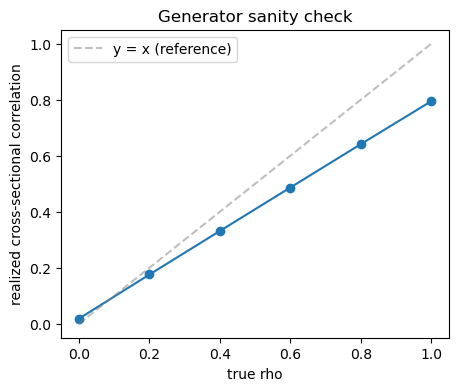

In [2]:
rhos_check = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
realized = []

for rho in rhos_check:
    gen = JumpDiffusionGenerator(n_assets=8, rho=rho, lambda_common=3.0, lambda_idio=1.0)
    paths = gen.simulate(n_steps=3000, dt=1 / 252, n_paths=1, seed=42)
    corr = gen.realized_cross_sectional_corr(paths)
    off_diag_mean = corr[np.triu_indices_from(corr, k=1)].mean()
    realized.append(off_diag_mean)
    print(f"rho={rho:.1f}  ->  mean off-diagonal realized corr = {off_diag_mean:.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(rhos_check, realized, "o-")
ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5, label="y = x (reference)")
ax.set_xlabel("true rho")
ax.set_ylabel("realized cross-sectional correlation")
ax.set_title("Generator sanity check")
ax.legend()
plt.show()


## 2. The task: contemporaneous leave-one-out reconstruction

**This is not the obvious choice, and the obvious choice (forecasting) is
actually broken for this generator** — worth understanding why before
looking at the pathways themselves.

`jump_diffusion_generator.py` draws every timestep's shock i.i.d. — there's
no serial autocorrelation in log-returns by construction. `rho` only shapes
how assets co-move *within* a timestep. So "predict asset i's return at
`t+1` from history through `t`" has no exploitable structure tied to `rho`,
at any rho value — an earlier version of this model targeted exactly that
and the loss barely moved off its initial-noise level no matter how long
training ran.

The task that actually depends on `rho`: for each asset `i` at time `t`,
predict `x[t, i]` from

- **cross-sectional pathway**: all *other* assets' values at the *same*
  timestep `t` — this is exactly what `rho` controls, so this pathway's
  achievable loss should improve as `rho` increases.
- **temporal pathway**: asset `i`'s own *strictly past* history, `x[<t, i]`
  — this carries no real signal at any `rho` (same i.i.d.-over-time
  property), so it should never get better or worse as `rho` changes.

The gate should end up reflecting which of those two (very different)
pathways is actually earning its keep.


## 3. Temporal pathway — causal, own-history only

A small causal 1D conv stack (shared weights across assets — same filter
applied independently to every asset's own series). "Causal" here means the
feature computed for position `t` depends only on `x[<t]`: the conv itself
computes features from `x[<=t]` and we then shift right by one so time `t`'s
feature is actually built from `x[<t]` before it ever reaches the head that
predicts `x[t]`. If this shift were wrong (off by one the other way), the
model could trivially "predict" `x[t]` using `x[t]` itself — worth checking
below since it's an easy bug to introduce silently.


In [3]:
temporal = TemporalPathway(hidden=8, kernel_size=3, n_layers=1)

# Feed a single batch, single asset series where we know the values.
# If temporal[:, t] only depends on x[<t], then changing x[t] should NOT
# change temporal[:, t]'s output -- only temporal[:, t+1:]'s outputs should move.
x_probe = torch.randn(1, 10, 1)
out_before = temporal(x_probe)

x_probe_perturbed = x_probe.clone()
x_probe_perturbed[0, 4, 0] += 100.0  # huge perturbation at t=4
out_after = temporal(x_probe_perturbed)

diff = (out_after - out_before).abs().sum(dim=-1).squeeze()  # (T,)
print("Per-timestep output change after perturbing x[t=4]:")
for t, d in enumerate(diff.tolist()):
    flag = "  <-- perturbation" if t == 4 else ("  <-- should move (t>4)" if t > 4 else "")
    print(f"  t={t:2d}  |change|={d:8.4f}{flag}")

assert diff[:5].abs().max() < 1e-5, "LEAK: output at or before t=4 changed when x[4] was perturbed!"
print("\nNo leak: outputs at t<=4 are unaffected by x[4], as expected for strictly-causal shifted features.")


Per-timestep output change after perturbing x[t=4]:
  t= 0  |change|=  0.0000
  t= 1  |change|=  0.0000
  t= 2  |change|=  0.0000
  t= 3  |change|=  0.0000
  t= 4  |change|=  0.0000  <-- perturbation
  t= 5  |change|=114.5346  <-- should move (t>4)
  t= 6  |change|=100.6938  <-- should move (t>4)
  t= 7  |change|= 65.6559  <-- should move (t>4)
  t= 8  |change|=  0.0000  <-- should move (t>4)
  t= 9  |change|=  0.0000  <-- should move (t>4)

No leak: outputs at t<=4 are unaffected by x[4], as expected for strictly-causal shifted features.


## 4. Cross-sectional pathway — leave-one-out, leak-proof by construction

Self-attention over the *asset* dimension at a single timestep. Two design
choices make this leak-proof, not just masked:

1. Asset `i` is masked out of its own key/value set (standard leave-one-out
   masking).
2. The attention **query** for asset `i` comes from a fixed, learned
   per-asset identity embedding — **not** from `x[t, i]` itself.

(2) matters because masking alone only guarantees the *aggregated values*
exclude asset `i`'s own value — the attention *weights* (how much each
other asset counts) could still be a function of `x[t, i]` if the query
were built from it, which would be a subtle leak. Using a fixed identity
embedding for the query closes that off entirely: the output for asset `i`
is *structurally* a function of `{x[t, j] : j != i}` only, regardless of
what the attention weights end up being.

Empirical check below: does the cross-sectional output for asset 0 actually
stay fixed when we change asset 0's own value, holding everyone else fixed?


In [4]:
n_assets = 6
cross = CrossSectionalPathway(hidden=8, n_assets=n_assets, n_heads=2)

x_probe = torch.randn(1, 3, n_assets)
out_before = cross(x_probe)

x_probe_perturbed = x_probe.clone()
x_probe_perturbed[0, :, 0] += 100.0  # huge perturbation to asset 0's own value, all timesteps

out_after = cross(x_probe_perturbed)

diff = (out_after - out_before).abs().sum(dim=-1).squeeze(0)  # (T, N)
print("Per-asset output change after perturbing asset 0's value (all timesteps):")
print(diff)

assert diff[:, 0].abs().max() < 1e-5, "LEAK: asset 0's own output changed when its own input was perturbed!"
print("\nNo leak: asset 0's output is unaffected by its own value; only assets 1-5 (who can see asset 0) move.")


Per-asset output change after perturbing asset 0's value (all timesteps):
tensor([[ 0.0000, 15.3259, 15.2595, 15.2904,  2.3497, 13.1176],
        [ 0.0000, 15.3160, 15.2875, 14.9295,  0.0547, 12.8473],
        [ 0.0000, 13.1294, 14.9568, 14.2413,  0.6984, 12.9818]],
       grad_fn=<SqueezeBackward1>)

No leak: asset 0's output is unaffected by its own value; only assets 1-5 (who can see asset 0) move.


## 5. The gate itself

```
h     = alpha * cross_sectional(x) + (1 - alpha) * temporal(x)
alpha = sigmoid(w)      # w: one trainable scalar, init alpha=0.5
```

`alpha` is exposed as a plain Python float via `model.alpha` for easy
logging/plotting.


In [5]:
model = GatedInterpolationModel(n_assets=10, hidden=16)
print("alpha at init:", model.alpha)
print("w (raw parameter) at init:", model.w.item())

x_demo = torch.randn(2, 20, 10)  # (batch=2, T=20, N=10 assets)
pred = model(x_demo)
print("prediction shape:", tuple(pred.shape), "(matches input shape -- reconstructs every (t, asset))")


alpha at init: 0.5
w (raw parameter) at init: 0.0
prediction shape: (2, 20, 10) (matches input shape -- reconstructs every (t, asset))


## 6. One live training run

Trains on a single `rho` value and plots loss + alpha over epochs, so you
can watch the gate move in real time rather than just reading a final
number.

**Why two optimizers?** `w` is optimized with plain SGD, separately from
the rest of the network (Adam). This isn't stylistic — Adam normalizes each
parameter's update by that parameter's own recent gradient magnitude, which
turned out to badly amplify the tiny-but-consistent gradient `w` gets when
there's little or no real signal (e.g. at true `rho=0`): alpha was drifting
upward purely from this artifact, with the loss barely moving. Plain SGD's
step size scales directly with the actual gradient, so negligible signal
stays negligible. Full story in `src/train.py`'s docstring and
`results/experiment1_findings.md`.

Pick a `rho` below and re-run the cell to see how the trajectory changes —
try `0.0` (nothing to find, alpha should stay roughly flat) vs `0.9` (real
signal, alpha should climb steadily).


[demo rho=0.6] starting training: 200 epochs, panel shape (30, 300, 10)


[demo rho=0.6] epoch    0/200  loss 1.0631  alpha 0.4642  (0.3s elapsed)


[demo rho=0.6] epoch   40/200  loss 0.5378  alpha 0.6829  (8.3s elapsed)


[demo rho=0.6] epoch   80/200  loss 0.5360  alpha 0.7114  (16.5s elapsed)


[demo rho=0.6] epoch  120/200  loss 0.5354  alpha 0.7245  (24.6s elapsed)


[demo rho=0.6] epoch  160/200  loss 0.5351  alpha 0.7304  (32.4s elapsed)


[demo rho=0.6] epoch  199/200  loss 0.5345  alpha 0.7365  (39.3s elapsed)


[demo rho=0.6] done in 39.3s -- final alpha 0.7365, final loss 0.5345


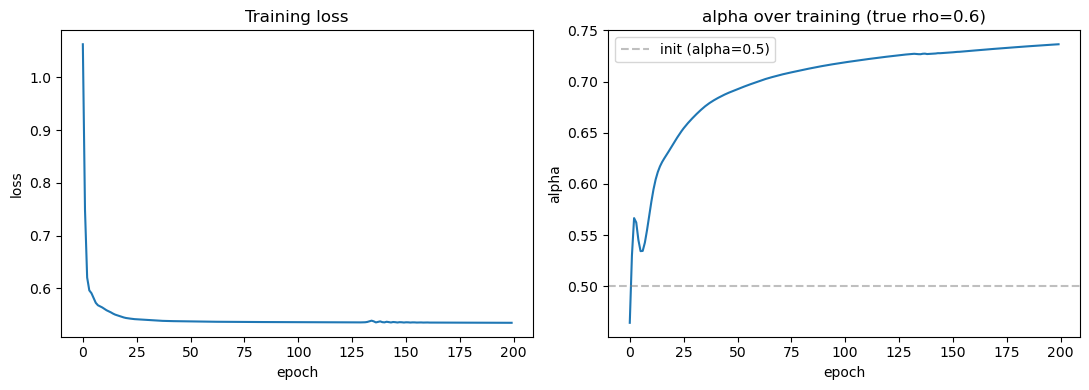

In [6]:
DEMO_RHO = 0.6

x_train = make_panel(rho=DEMO_RHO, n_assets=10, n_paths=30, n_steps=300, seed=0)
out = train_one_run(x_train, epochs=200, seed=0, log_every=40, tag=f"[demo rho={DEMO_RHO}]")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(out["loss_history"])
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Training loss")

axes[1].plot(out["alpha_history"])
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="init (alpha=0.5)")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("alpha"); axes[1].set_title(f"alpha over training (true rho={DEMO_RHO})")
axes[1].legend()
plt.tight_layout()
plt.show()


## 7. Experiment 1 results: does alpha recover rho across the full grid?

Loads the saved grid sweep from `experiments/experiment1_recovery.py`
(results at `results/experiment1_recovery.csv`, write-up at
`results/experiment1_findings.md`). Re-run that script if you've changed
the model/training code and want fresh numbers here.


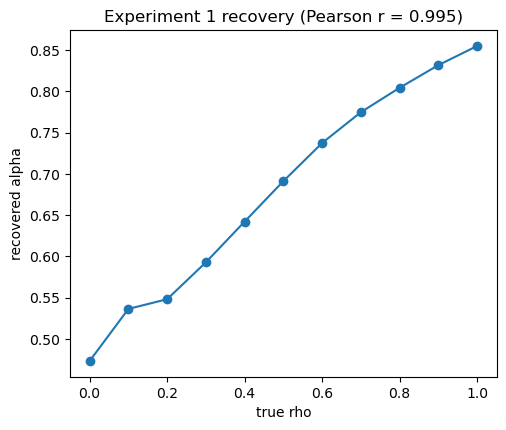

Pearson corr(rho, alpha) = 0.9947
Monotonic: True


In [7]:
import csv

with open("../results/experiment1_recovery.csv") as f:
    reader = csv.DictReader(f)
    rows = list(reader)

rhos = np.array([float(r["rho"]) for r in rows])
alphas = np.array([float(r["alpha"]) for r in rows])
corr = np.corrcoef(rhos, alphas)[0, 1]

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(rhos, alphas, "o-", color="C0")
ax.set_xlabel("true rho")
ax.set_ylabel("recovered alpha")
ax.set_title(f"Experiment 1 recovery (Pearson r = {corr:.3f})")
ax.set_xlim(-0.05, 1.05)
plt.show()

print(f"Pearson corr(rho, alpha) = {corr:.4f}")
print("Monotonic:", all(alphas[i] <= alphas[i+1] for i in range(len(alphas) - 1)))


Note the curve is compressed toward the middle (roughly 0.47 -> 0.86) rather
than spanning the full [0, 1] range — see `results/experiment1_findings.md`
for why that's expected here (the temporal pathway carries zero real signal
at *any* rho under this generator, so the gate is choosing between "one
informative pathway" and "no signal at all," not trading off two genuinely
competing signals). Monotonicity is the thing to check, not linearity.

**Next step per the spec:** Experiment 2 — compare `alpha` against the
trivial realized-correlation baseline. If the baseline matches `alpha`'s
performance, the NN machinery isn't earning its complexity for this
question.
